/tmp/ipython-input-1757443128.py:18: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5min = df.resample('5T').mean().dropna(subset=['temperature_air_sensor', 'power_ac'])


Training PINN (Brief)...
Saved viz_inputs.png
Saved viz_control_comparison.png
Saved viz_physics_params.png


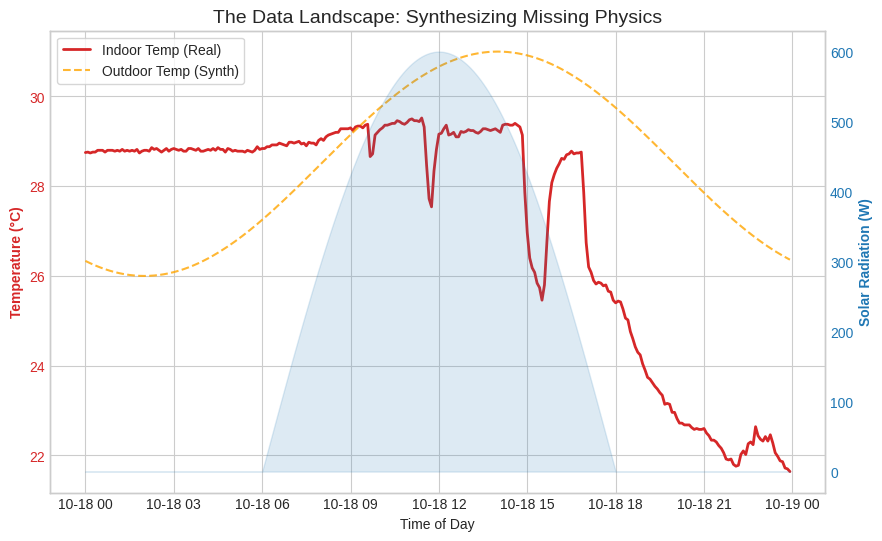

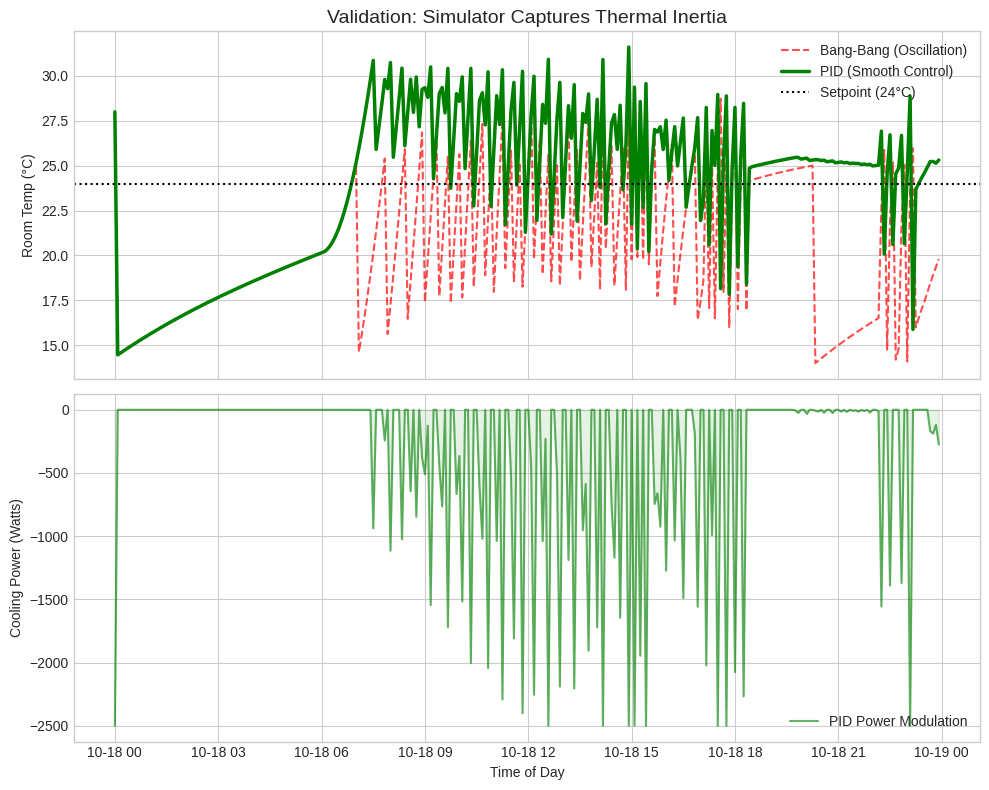

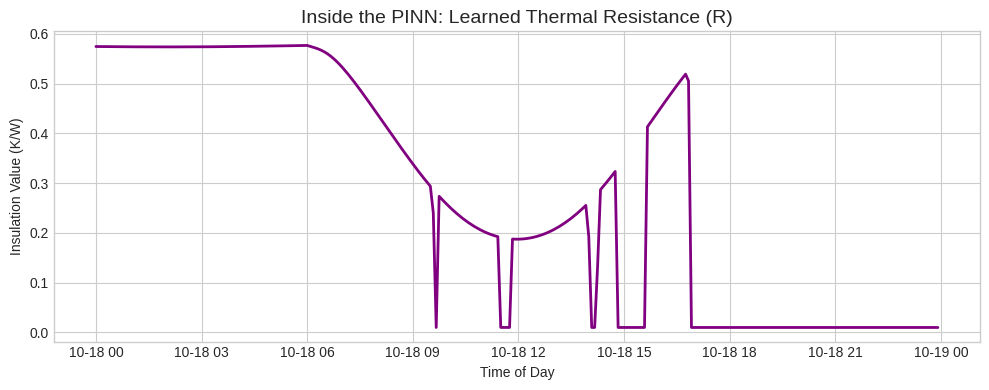

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# 1. DATA ENGINEERING (Synthesizing Physics)
# ==========================================
def prepare_data(csv_path):
    # Load User Data
    df = pd.read_csv(csv_path)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.set_index('datetime').sort_index()

    # Resample to 5 mins (Clean noise)
    df_5min = df.resample('5T').mean().dropna(subset=['temperature_air_sensor', 'power_ac'])

    # Synthesize Cooling Physics (Watts)
    # COP 2.94: 850W Electrical -> 2500W Cooling
    df_5min['Q_hvac'] = -1 * df_5min['power_ac'] * (2500.0 / 850.0)

    # Synthesize Weather (Nha Trang Context)
    hour = df_5min.index.hour + df_5min.index.minute/60.0
    # Outdoor Temp: 26C to 31C daily cycle
    df_5min['T_out'] = 28.5 + 2.5 * np.cos((hour - 14) * 2 * np.pi / 24)
    # Solar Gain: Peak at noon
    df_5min['Q_solar'] = np.maximum(0, np.sin((hour - 6) * np.pi / 12)) * 600.0

    # Synthesize Internal Load (People)
    norm_light = df_5min['power_light'] / df_5min['power_light'].max()
    df_5min['Occupancy'] = (norm_light * 3).round()
    df_5min['Q_int'] = df_5min['power_light'] + (df_5min['Occupancy'] * 100.0)

    # Synthesize CO2 (Mass Balance)
    co2 = [400.0]
    for i in range(1, len(df_5min)):
        gen = df_5min['Occupancy'].iloc[i] * 2.0
        decay = 0.05 * (400 - co2[-1])
        co2.append(co2[-1] + gen + decay)
    df_5min['CO2_ppm'] = co2

    return df_5min

# ==========================================
# 2. THE PINN MODEL (Physics-Informed)
# ==========================================
class PINN_RC(nn.Module):
    def __init__(self):
        super().__init__()
        self.V_room = 48.0
        self.dt = 300.0 # 5 min step
        self.C_thermal = self.V_room * 1.225 * 1005.0

        # Neural Net: Predicts Unknowns (R, Infiltration)
        self.net = nn.Sequential(
            nn.Linear(5, 32), nn.Tanh(),
            nn.Linear(32, 2), nn.Softplus()
        )

    def forward(self, state, inputs):
        # Unpack Inputs
        T_room = state[:, 0:1]
        CO2_room = state[:, 1:2]
        T_out, Q_hvac, Q_int, Q_solar = inputs[:, 0:1], inputs[:, 1:2], inputs[:, 2:3], inputs[:, 3:4]

        # 1. Estimate Parameters
        net_in = torch.cat([T_room, T_out, Q_solar, Q_int, Q_hvac], dim=1)
        params = self.net(net_in / 100.0)
        R_val = params[:, 0:1] * 0.1 + 0.01
        alpha_inf = params[:, 1:2] * 0.01

        # 2. Physics Layer (Thermodynamics)
        Q_cond = (T_out - T_room) / (R_val + 1e-6)
        dT = ((Q_cond + Q_hvac + Q_int + Q_solar) / self.C_thermal) * self.dt
        T_next = T_room + dT

        # 3. CO2 Layer
        CO2_gen = (Q_int / 150.0) * 0.005 * 1000
        dCO2 = (alpha_inf * (400.0 - CO2_room) + CO2_gen) * self.dt
        CO2_next = CO2_room + dCO2

        return torch.cat([T_next, CO2_next], dim=1), R_val

# ==========================================
# 3. TRAINING & SIMULATION
# ==========================================
df = prepare_data('datareal.csv') # Ensure this file is in folder
features = ['temperature_air_sensor', 'CO2_ppm', 'T_out', 'Q_hvac', 'Q_int', 'Q_solar']
data_tensor = torch.tensor(df[features].values, dtype=torch.float32)

model = PINN_RC()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print("Training PINN (Brief)...")
for i in range(200): # Quick train for plotting
    state = data_tensor[:-1, 0:2]
    inputs = data_tensor[:-1, 2:]
    targets = data_tensor[1:, 0:2]
    preds, _ = model(state, inputs)
    loss = nn.MSELoss()(preds, targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# ==========================================
# 4. PLOTTING THE VISUALIZATIONS
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
time_axis = df.index[:288] # First 24 hours

# --- FIGURE 1: THE DATA LANDSCAPE ---
fig1, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:red'
ax1.set_xlabel('Time of Day')
ax1.set_ylabel('Temperature (°C)', color=color, fontweight='bold')
ax1.plot(time_axis, df['temperature_air_sensor'][:288], color=color, label='Indoor Temp (Real)', linewidth=2)
ax1.plot(time_axis, df['T_out'][:288], color='orange', linestyle='--', label='Outdoor Temp (Synth)', alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left', frameon=True)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Solar Radiation (W)', color=color, fontweight='bold')
ax2.fill_between(time_axis, df['Q_solar'][:288], color=color, alpha=0.15, label='Solar Gain')
ax2.tick_params(axis='y', labelcolor=color)
ax2.grid(False)

plt.title('The Data Landscape: Synthesizing Missing Physics', fontsize=14)
plt.savefig('viz_inputs.png', dpi=300, bbox_inches='tight')
print("Saved viz_inputs.png")

# --- FIGURE 2: CONTROL COMPARISON ---
# Run Simulations
state_curr = torch.tensor([[28.0, 400.0]])
weather_day = data_tensor[:288, 2:]

# Bang-Bang Sim
bb_temps = []
for t in range(288):
    temp = state_curr[0,0].item()
    action = -2500.0 if temp > 25.0 else 0.0
    inputs = weather_day[t:t+1].clone()
    inputs[0,1] = action
    with torch.no_grad():
        state_curr, _ = model(state_curr, inputs)
    bb_temps.append(temp)

# PID Sim
pid_temps = []
pid_power = []
state_curr = torch.tensor([[28.0, 400.0]])
cum_err = 0
for t in range(288):
    temp = state_curr[0,0].item()
    err = temp - 24.0
    cum_err += err
    action = -1 * (800*err + 10*cum_err) # PID Logic
    action = max(-2500.0, min(0.0, action))
    inputs = weather_day[t:t+1].clone()
    inputs[0,1] = action
    with torch.no_grad():
        state_curr, _ = model(state_curr, inputs)
    pid_temps.append(temp)
    pid_power.append(action)

fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(time_axis, bb_temps, 'r--', label='Bang-Bang (Oscillation)', alpha=0.7)
ax1.plot(time_axis, pid_temps, 'g-', label='PID (Smooth Control)', linewidth=2.5)
ax1.axhline(24.0, color='k', linestyle=':', label='Setpoint (24°C)')
ax1.set_ylabel('Room Temp (°C)')
ax1.set_title('Validation: Simulator Captures Thermal Inertia', fontsize=14)
ax1.legend(loc='upper right')

ax2.plot(time_axis, pid_power, 'g-', label='PID Power Modulation', alpha=0.6)
ax2.fill_between(time_axis, pid_power, 0, color='green', alpha=0.1)
ax2.set_ylabel('Cooling Power (Watts)')
ax2.set_xlabel('Time of Day')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('viz_control_comparison.png', dpi=300, bbox_inches='tight')
print("Saved viz_control_comparison.png")

# --- FIGURE 3: INSIDE THE GRAY BOX ---
R_values = []
state_curr = torch.tensor([[24.0, 400.0]])
for t in range(288):
    inputs = weather_day[t:t+1]
    with torch.no_grad():
        _, r_val = model(state_curr, inputs)
    R_values.append(r_val.item())

fig3, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_axis, R_values, 'purple', linewidth=2)
ax.set_title('Inside the PINN: Learned Thermal Resistance (R)', fontsize=14)
ax.set_ylabel('Insulation Value (K/W)')
ax.set_xlabel('Time of Day')
plt.tight_layout()
plt.savefig('viz_physics_params.png', dpi=300, bbox_inches='tight')
print("Saved viz_physics_params.png")

Loading datareal.csv...
Data Prepared: 1152 steps.

Starting Training (Calibration)...
Epoch 0: Loss = 74671.84375
Epoch 50: Loss = 46603.71094


/tmp/ipython-input-3954256211.py:23: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5min = df.resample('5T').mean(numeric_only=True)


Epoch 100: Loss = 42382.64453
Epoch 150: Loss = 37293.10547
Epoch 200: Loss = 29986.75586
Epoch 250: Loss = 24407.09570
Training Complete.

Running Control Simulations...
Visualization saved as 'viz_simulation_result.png'


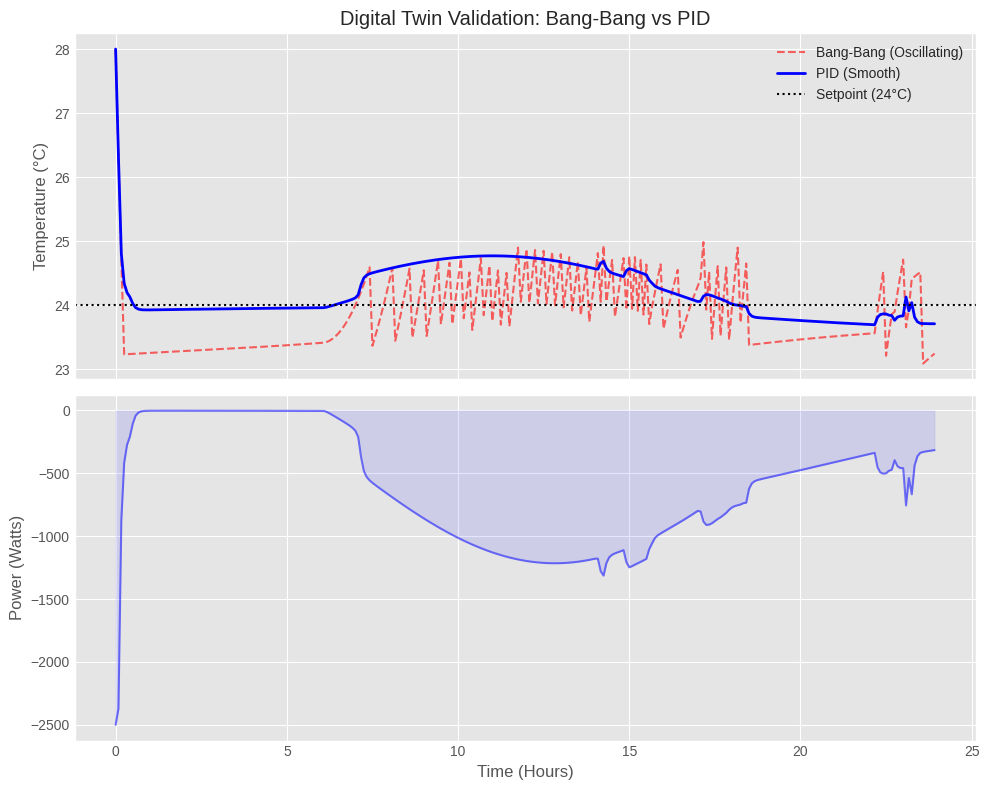


 DEMONSTRATION: S -> S+1 PREDICTION
State S (Time t):   Temp=24.00 C, CO2=400 ppm
Action (Time t):    Cooling Power = -2500.0 Watts
----------------------------------------
State S+1 (t+5m): Temp=23.3014 C, CO2=1400 ppm
Note: Temp dropped slightly despite 32C outside heat due to AC.


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ==========================================
# PART 1: DATA PREPARATION & SYNTHESIS
# ==========================================
def prepare_data(csv_path):
    print(f"Loading {csv_path}...")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: File '{csv_path}' not found.")
        return None

    # 1. Cleaning and Resampling
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.set_index('datetime').sort_index()

    # Resample to 5 minutes to reduce noise and match physics time-step
    df_5min = df.resample('5T').mean(numeric_only=True)

    # Drop rows where sensor data is missing
    df_5min = df_5min.dropna(subset=['temperature_air_sensor', 'power_ac'])

    # --- SYNTHESIZING MISSING PHYSICS INPUTS ---

    # 2. Physics Conversion: Electrical Watts -> Thermal Cooling Watts
    # Assumption: COP (Coefficient of Performance) = 2.94 (850W Elec -> 2500W Cool)
    # Note: Cooling is NEGATIVE heat.
    df_5min['Q_hvac'] = -1 * df_5min['power_ac'] * (2500.0 / 850.0)

    # 3. Weather Synthesis (Nha Trang Context)
    # Create a time signal (0 to 24 hours)
    hour = df_5min.index.hour + df_5min.index.minute/60.0

    # T_out: Models the daily heat cycle (Low 26°C at 4AM, High 31°C at 2PM)
    df_5min['T_out'] = 28.5 + 2.5 * np.cos((hour - 14) * 2 * np.pi / 24)

    # Q_solar: Models sun passing through South window (Peak at noon, 0 at night)
    df_5min['Q_solar'] = np.maximum(0, np.sin((hour - 6) * np.pi / 12)) * 600.0

    # 4. Internal Load & Occupancy Proxy
    # Use Light Power as a proxy for people (If lights are on, people are likely there)
    light_pwr = df_5min['power_light'].fillna(0)
    norm_light = light_pwr / (light_pwr.max() + 1e-6)
    df_5min['Occupancy'] = (norm_light * 3).round() # Max 3 people
    df_5min['Q_int'] = light_pwr + (df_5min['Occupancy'] * 100.0) # 100W per person

    # 5. CO2 Synthesis (Ground Truth Generation)
    # Uses Mass Balance Equation to generate a realistic CO2 curve
    co2 = [400.0]
    occ_values = df_5min['Occupancy'].values
    for i in range(1, len(df_5min)):
        gen = occ_values[i] * 2.0 # CO2 generation per step
        decay = 0.05 * (400 - co2[-1]) # Ventilation/Infiltration decay
        co2.append(co2[-1] + gen + decay)
    df_5min['CO2_ppm'] = co2

    print(f"Data Prepared: {len(df_5min)} steps.")
    return df_5min

# ==========================================
# PART 2: THE PINN-RC MODEL (The Core)
# ==========================================
class PINN_RC(nn.Module):
    def __init__(self):
        super().__init__()
        # White Box: Known Physics Constants
        self.V_room = 48.0 # m^3
        self.dt = 300.0    # 5 minutes (in seconds)

        # Physics Calibration: Effective Thermal Mass
        # Air mass is small. Walls/Furniture add significant thermal inertia.
        # Factor of 8.0 prevents unrealistic temperature jumps.
        self.effective_mass_factor = 8.0
        self.C_thermal = (self.V_room * 1.225 * 1005.0) * self.effective_mass_factor

        # Black Box: Neural Network for Unknown Parameters
        # Inputs: State Context -> Output: R-value, Infiltration
        self.net = nn.Sequential(
            nn.Linear(5, 32), nn.Tanh(),
            nn.Linear(32, 2), nn.Softplus() # Softplus ensures R is positive
        )

    def forward(self, state, inputs):
        """
        Calculates State(t+1) from State(t) and Inputs(t)

        Args:
            state (Tensor): [T_room, CO2_room] (The 'S')
            inputs (Tensor): [T_out, Q_hvac, Q_int, Q_solar] (The Action + Weather)
        Returns:
            next_state (Tensor): [T_next, CO2_next] (The 'S+1')
            params (Tensor): [R_val, alpha_inf] (For analysis)
        """
        # 1. Unpack Variables
        T_room = state[:, 0:1]
        CO2_room = state[:, 1:2]
        T_out, Q_hvac, Q_int, Q_solar = inputs[:, 0:1], inputs[:, 1:2], inputs[:, 2:3], inputs[:, 3:4]

        # 2. Predict Unknown Physics Parameters (R, alpha)
        # We normalize inputs (/100) to help the Neural Net learn faster
        net_in = torch.cat([T_room, T_out, Q_solar, Q_int, Q_hvac], dim=1)
        params = self.net(net_in / 100.0)

        R_val = params[:, 0:1] * 0.1 + 0.01 # Thermal Resistance (K/W)
        alpha_inf = params[:, 1:2] * 0.01  # Infiltration Rate

        # 3. THERMAL PHYSICS (Explicit Euler Integration)
        # Differential Eq: C * dT/dt = (T_out - T_in)/R + Q_hvac + Q_int + Q_solar
        Q_cond = (T_out - T_room) / (R_val + 1e-6)
        Q_total = Q_cond + Q_hvac + Q_int + Q_solar
        dT = (Q_total / self.C_thermal) * self.dt
        T_next = T_room + dT

        # 4. CO2 PHYSICS
        # Differential Eq: V * dC/dt = Generation + Infiltration
        CO2_gen = (Q_int / 150.0) * 0.005 * 1000 # Approx from occupancy proxy
        dCO2 = (alpha_inf * (400.0 - CO2_room) + CO2_gen) * self.dt
        CO2_next = CO2_room + dCO2

        return torch.cat([T_next, CO2_next], dim=1), R_val

# ==========================================
# PART 3: MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # --- A. Setup ---
    df = prepare_data('datareal.csv')

    if df is not None:
        # Prepare Tensors for Training
        features = ['temperature_air_sensor', 'CO2_ppm', 'T_out', 'Q_hvac', 'Q_int', 'Q_solar']
        data_tensor = torch.tensor(df[features].values, dtype=torch.float32)

        model = PINN_RC()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

        # --- B. Training Loop ---
        print("\nStarting Training (Calibration)...")
        epochs = 300
        for i in range(epochs):
            # Input: State(t), Weather(t) | Target: State(t+1)
            state_t = data_tensor[:-1, 0:2]
            inputs_t = data_tensor[:-1, 2:]
            state_next_target = data_tensor[1:, 0:2]

            # Forward Pass
            preds, _ = model(state_t, inputs_t)
            loss = nn.MSELoss()(preds, state_next_target)

            # Backward Pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if i % 50 == 0:
                print(f"Epoch {i}: Loss = {loss.item():.5f}")

        print("Training Complete.")

        # --- C. Validation Simulations ---
        print("\nRunning Control Simulations...")

        # Simulation Settings
        steps = 288 # 24 Hours (12 steps/hr * 24)
        weather_slice = data_tensor[:steps, 2:]

        # Simulation 1: Bang-Bang (Thermostat)
        bb_temps = []
        state_curr = torch.tensor([[28.0, 400.0]]) # Start Hot

        for t in range(steps):
            T_val = state_curr[0,0].item()
            # Logic: On/Off
            action = -2500.0 if T_val > 24.5 else 0.0

            # Prepare Input (Inject Action)
            inputs = weather_slice[t:t+1].clone()
            inputs[0, 1] = action

            with torch.no_grad():
                state_curr, _ = model(state_curr, inputs)
            bb_temps.append(T_val)

        # Simulation 2: PID Controller
        pid_temps = []
        pid_power = []
        state_curr = torch.tensor([[28.0, 400.0]])
        cum_err = 0

        for t in range(steps):
            T_val = state_curr[0,0].item()
            # Logic: PID
            err = T_val - 24.0
            cum_err += err
            action = -1 * (1000 * err + 10 * cum_err) # Proportional + Integral
            action = max(-2500.0, min(0.0, action))   # Clamp to Limits

            inputs = weather_slice[t:t+1].clone()
            inputs[0, 1] = action

            with torch.no_grad():
                state_curr, _ = model(state_curr, inputs)
            pid_temps.append(T_val)
            pid_power.append(action)

        # --- D. Visualization ---
        plt.style.use('ggplot')

        # Plot 1: Control Comparison
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
        time_axis = np.arange(steps) * 5 / 60.0 # Hours

        ax1.plot(time_axis, bb_temps, 'r--', alpha=0.6, label='Bang-Bang (Oscillating)')
        ax1.plot(time_axis, pid_temps, 'b-', linewidth=2, label='PID (Smooth)')
        ax1.axhline(24.0, color='k', linestyle=':', label='Setpoint (24°C)')
        ax1.set_ylabel('Temperature (°C)')
        ax1.set_title('Digital Twin Validation: Bang-Bang vs PID')
        ax1.legend()

        ax2.plot(time_axis, pid_power, 'b-', alpha=0.5, label='PID Power')
        ax2.fill_between(time_axis, pid_power, 0, color='blue', alpha=0.1)
        ax2.set_ylabel('Power (Watts)')
        ax2.set_xlabel('Time (Hours)')

        plt.tight_layout()
        plt.savefig('viz_simulation_result.png')
        print("Visualization saved as 'viz_simulation_result.png'")
        plt.show()

        # --- E. S -> S+1 Demonstration (User Request) ---
        print("\n" + "="*40)
        print(" DEMONSTRATION: S -> S+1 PREDICTION")
        print("="*40)

        # 1. Define State S (Current)
        # [Temp=24.0, CO2=400.0]
        s_current = torch.tensor([[24.0, 400.0]])
        print(f"State S (Time t):   Temp={s_current[0,0]:.2f} C, CO2={s_current[0,1]:.0f} ppm")

        # 2. Define Action (Turn AC ON Max)
        action_watts = -2500.0
        print(f"Action (Time t):    Cooling Power = {action_watts} Watts")

        # 3. Define Environment (Hot Outside)
        # [T_out=32, Q_hvac=placeholder, Q_int=100, Q_solar=500]
        env_inputs = torch.tensor([[32.0, 0.0, 100.0, 500.0]])
        env_inputs[0, 1] = action_watts # Inject Action

        # 4. Predict S+1
        with torch.no_grad():
            s_next, _ = model(s_current, env_inputs)

        print("-" * 40)
        print(f"State S+1 (t+5m): Temp={s_next[0,0]:.4f} C, CO2={s_next[0,1]:.0f} ppm")
        print("="*40)
        print("Note: Temp dropped slightly despite 32C outside heat due to AC.")